# Week 4 · Notebook 1 — The ELBO and Mean-Field Variational Inference

## Learning objectives

1. Derive the **evidence lower bound (ELBO)** from the KL divergence between an approximate posterior $q(z)$ and the true posterior $p(z\mid x)$.
2. Understand why maximising the ELBO is equivalent to minimising $\mathrm{KL}(q\,\Vert\,p)$.
3. Implement **mean-field VI** for a univariate Gaussian model and compare against the exact posterior.
4. Visualise the variational tightening of the bound across iterations.

---

## 1. From KL divergence to the ELBO

Let $x$ be observed data and $z$ a latent variable. The true posterior is
$$
p(z\mid x) = \frac{p(x,z)}{p(x)}, \qquad p(x)=\int p(x,z)\,dz.
$$
Computing $p(x)$ is usually intractable. Variational inference replaces it by **optimisation**: pick a tractable family $\mathcal{Q}$ and find
$$
q^*(z) = \arg\min_{q\in\mathcal{Q}}\; \mathrm{KL}\bigl(q(z)\,\Vert\,p(z\mid x)\bigr).
$$
Expanding the KL,
$$
\mathrm{KL}(q\Vert p(\cdot\mid x))
 = \mathbb{E}_q[\log q(z)] - \mathbb{E}_q[\log p(z\mid x)]
 = \mathbb{E}_q[\log q(z)] - \mathbb{E}_q[\log p(x,z)] + \log p(x).
$$
Re-arranging,
$$
\boxed{\;\log p(x) = \underbrace{\mathbb{E}_q[\log p(x,z)] - \mathbb{E}_q[\log q(z)]}_{\mathcal{L}(q)\;=\;\text{ELBO}} + \mathrm{KL}(q\Vert p(\cdot\mid x)).\;}
$$
Because $\mathrm{KL}\ge 0$, $\log p(x) \ge \mathcal{L}(q)$ — hence the name *evidence lower bound*. Maximising $\mathcal{L}(q)$ over $\mathcal{Q}$ is equivalent to minimising the KL.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN = '#5B7DB1', '#C46D5E', '#7CA982'


## 2. A worked example — Gaussian with unknown mean and precision

We use the standard textbook example (Bishop §10.1.3). Observe $x_{1:N}\sim\mathcal{N}(\mu, \tau^{-1})$ with conjugate priors
$$
p(\mu\mid\tau)=\mathcal{N}(\mu_0,(\lambda_0\tau)^{-1}),\qquad p(\tau)=\mathrm{Gamma}(a_0,b_0).
$$
The **exact** posterior is Normal–Gamma. We will approximate it by a *factorised* variational distribution
$$
q(\mu,\tau) = q_\mu(\mu)\,q_\tau(\tau)
$$
and watch it recover the true posterior in the large-data limit.


In [2]:
# True data-generating parameters
mu_true, tau_true = 2.0, 4.0     # variance = 1/4
N = 30
x = rng.normal(mu_true, 1/np.sqrt(tau_true), N)
xbar, S = x.mean(), ((x - x.mean())**2).sum()
print(f'sample mean = {xbar:.3f},  sample var = {S/N:.3f}')

# Priors (weakly informative)
mu0, lam0, a0, b0 = 0.0, 0.01, 0.001, 0.001


sample mean = 1.939,  sample var = 0.164


### 2.1 Mean-field update equations

The general mean-field result is that the optimal factor for the $j$-th group is
$$
\log q_j^*(z_j) = \mathbb{E}_{q_{-j}}[\log p(x,z)] + \text{const}.
$$
Applied here, both factors are recognisable:
$$
q_\mu(\mu) = \mathcal{N}(\mu_N, \lambda_N^{-1}),\qquad
q_\tau(\tau) = \mathrm{Gamma}(a_N, b_N),
$$
with coupled updates
$$
\mu_N = \frac{\lambda_0\mu_0 + N\bar{x}}{\lambda_0 + N},\quad
\lambda_N = (\lambda_0 + N)\,\mathbb{E}[\tau],
$$
$$
a_N = a_0 + \tfrac{N+1}{2},\quad
b_N = b_0 + \tfrac{1}{2}\mathbb{E}_\mu\!\Bigl[\sum_n (x_n-\mu)^2 + \lambda_0(\mu-\mu_0)^2\Bigr].
$$
The expectation under $q_\mu$ of $(x_n-\mu)^2$ uses $\mathbb{E}[\mu]=\mu_N$ and $\mathrm{Var}[\mu]=1/\lambda_N$.


In [3]:
def elbo(x, mu0, lam0, a0, b0, muN, lamN, aN, bN):
    # Closed-form ELBO for the Gaussian/NormalGamma mean-field model.
    from scipy.special import digamma, gammaln
    N = len(x)
    E_tau = aN / bN
    E_log_tau = digamma(aN) - np.log(bN)
    E_mu = muN
    E_mu2 = 1/lamN + muN**2

    # E[log p(x|mu,tau)]
    sq = (x**2).sum() - 2*E_mu*x.sum() + N*E_mu2
    Elp_x = 0.5*N*(E_log_tau - np.log(2*np.pi)) - 0.5*E_tau*sq
    # E[log p(mu|tau)]
    Elp_mu = 0.5*(np.log(lam0) + E_log_tau - np.log(2*np.pi)) \
             - 0.5*lam0*E_tau*((E_mu - mu0)**2 + 1/lamN)
    # E[log p(tau)]
    Elp_tau = a0*np.log(b0) - gammaln(a0) + (a0-1)*E_log_tau - b0*E_tau
    # -E[log q(mu)]
    H_mu = 0.5*(np.log(2*np.pi/lamN) + 1)
    # -E[log q(tau)]
    H_tau = aN - np.log(bN) + gammaln(aN) + (1-aN)*digamma(aN)
    return Elp_x + Elp_mu + Elp_tau + H_mu + H_tau

# Initialise
muN, lamN = xbar, 1.0
aN, bN = a0 + (N+1)/2, b0 + 1.0
hist = []
for it in range(40):
    # q_mu update
    E_tau = aN / bN
    lamN = (lam0 + N) * E_tau
    muN = (lam0*mu0 + N*xbar) / (lam0 + N)
    # q_tau update
    E_mu, V_mu = muN, 1/lamN
    bN = b0 + 0.5*((x**2).sum() - 2*E_mu*x.sum() + N*(V_mu + E_mu**2)
                   + lam0*((E_mu-mu0)**2 + V_mu))
    L = elbo(x, mu0, lam0, a0, b0, muN, lamN, aN, bN)
    hist.append(L)

print(f'converged ELBO = {hist[-1]:.4f}')
print(f'q_mu  ≈ N({muN:.3f}, {1/lamN:.4f})')
print(f'q_tau ≈ Gamma({aN:.3f}, {bN:.3f}),   E[tau] = {aN/bN:.3f}')


converged ELBO = -26.9041
q_mu  ≈ N(1.939, 0.0055)
q_tau ≈ Gamma(15.501, 2.558),   E[tau] = 6.060


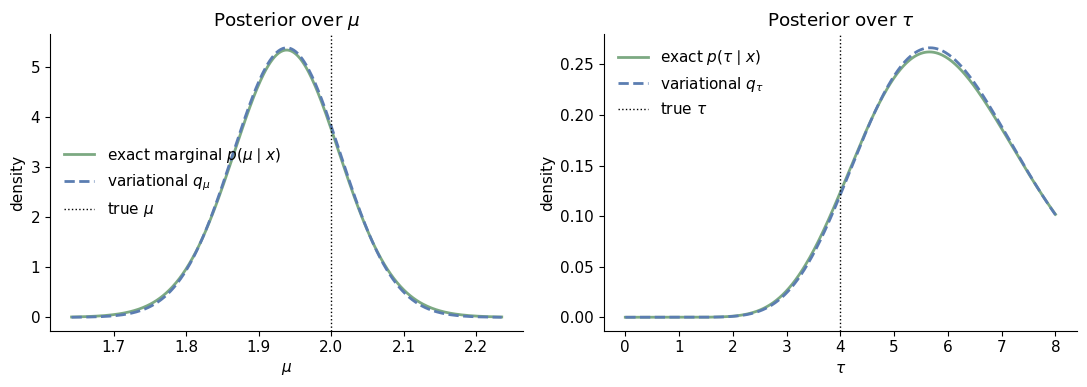

In [4]:
# Compare with the exact Normal-Gamma posterior (conjugate update).
muP = (lam0*mu0 + N*xbar) / (lam0 + N)
lamP = lam0 + N
aP = a0 + N/2
bP = b0 + 0.5*S + 0.5 * lam0*N*(xbar - mu0)**2 / (lam0 + N)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mu_grid = np.linspace(muN - 4/np.sqrt(lamN), muN + 4/np.sqrt(lamN), 400)
# Marginal of mu under Normal-Gamma is a Student-t
from scipy.stats import t as student_t
scale_t = np.sqrt(bP/(aP*lamP))
axes[0].plot(mu_grid, student_t.pdf(mu_grid, df=2*aP, loc=muP, scale=scale_t),
             color=GREEN, lw=2, label='exact marginal $p(\\mu\\mid x)$')
axes[0].plot(mu_grid, stats.norm.pdf(mu_grid, muN, 1/np.sqrt(lamN)),
             '--', color=BLUE, lw=2, label='variational $q_\\mu$')
axes[0].axvline(mu_true, color='k', ls=':', lw=1, label='true $\\mu$')
axes[0].set(xlabel='$\\mu$', ylabel='density', title='Posterior over $\\mu$')
axes[0].legend(frameon=False)

tau_grid = np.linspace(1e-3, 8, 400)
axes[1].plot(tau_grid, stats.gamma.pdf(tau_grid, aP, scale=1/bP),
             color=GREEN, lw=2, label='exact $p(\\tau\\mid x)$')
axes[1].plot(tau_grid, stats.gamma.pdf(tau_grid, aN, scale=1/bN),
             '--', color=BLUE, lw=2, label='variational $q_\\tau$')
axes[1].axvline(tau_true, color='k', ls=':', lw=1, label='true $\\tau$')
axes[1].set(xlabel='$\\tau$', ylabel='density', title='Posterior over $\\tau$')
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()


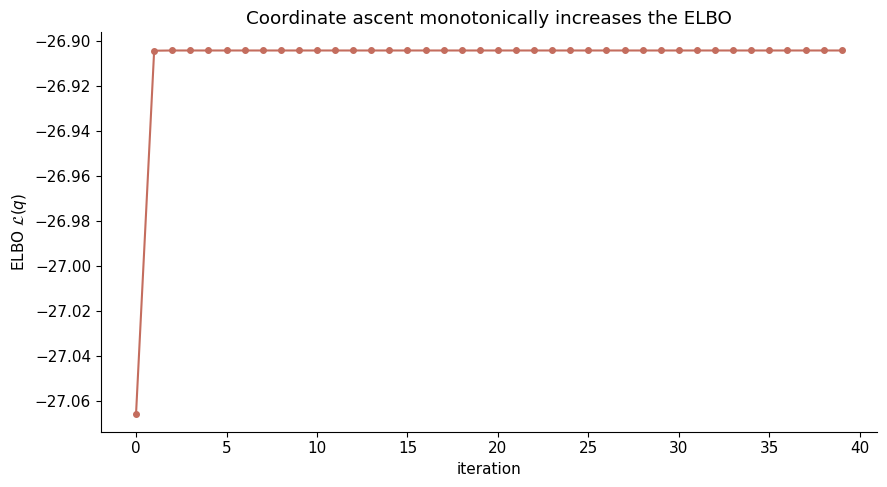

min increment = -4.62e-14  (must be >= 0)


In [5]:
# ELBO monotonicity check.
plt.figure()
plt.plot(hist, '-o', color=RED, ms=4)
plt.xlabel('iteration'); plt.ylabel('ELBO $\\mathcal{L}(q)$')
plt.title('Coordinate ascent monotonically increases the ELBO')
plt.tight_layout(); plt.show()

deltas = np.diff(hist)
print(f'min increment = {deltas.min():.2e}  (must be >= 0)')


## 3. Why does mean-field underestimate variance?

Mean-field VI factorises across latent groups. Under $\mathrm{KL}(q\Vert p)$ the optimiser is **mode-seeking**: $q$ avoids placing mass where $p$ has none. For correlated posteriors, a factorised $q$ therefore tends to *contract* and underestimate marginal variances. Compare the contours below for a correlated bivariate Gaussian target.


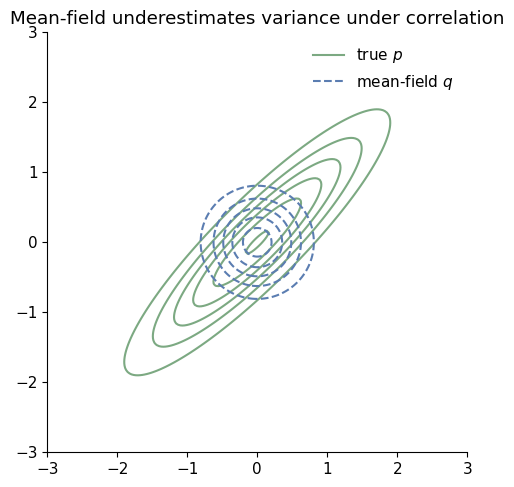

exact marginal sd  = [1. 1.]
mean-field sd      = [0.43588989 0.43588989]


In [6]:
# Toy: target N(0, Sigma) with strong correlation; q = N(mu_q, diag).
Sigma = np.array([[1.0, 0.9], [0.9, 1.0]])
Lambda = np.linalg.inv(Sigma)
# Mean-field optimum: q_i = N(0, 1/Lambda_ii)
sd_mf = 1 / np.sqrt(np.diag(Lambda))

xs = np.linspace(-3, 3, 200); X, Y = np.meshgrid(xs, xs)
pos = np.dstack([X, Y])
pdf_true = stats.multivariate_normal(mean=[0,0], cov=Sigma).pdf(pos)
pdf_mf = (stats.norm.pdf(X, 0, sd_mf[0]) * stats.norm.pdf(Y, 0, sd_mf[1]))

plt.figure(figsize=(6, 5))
plt.contour(X, Y, pdf_true, levels=6, colors=GREEN, linewidths=1.5)
plt.contour(X, Y, pdf_mf, levels=6, colors=BLUE, linewidths=1.5, linestyles='--')
plt.plot([], [], color=GREEN, label='true $p$')
plt.plot([], [], '--', color=BLUE, label='mean-field $q$')
plt.legend(frameon=False); plt.gca().set_aspect('equal')
plt.title('Mean-field underestimates variance under correlation')
plt.tight_layout(); plt.show()

print('exact marginal sd  =', np.sqrt(np.diag(Sigma)))
print('mean-field sd      =', sd_mf)


## 4. Summary

- The ELBO decomposes $\log p(x)$ into a tractable lower bound plus a KL term.
- Mean-field VI updates each factor in closed form when the model is in the conditionally conjugate exponential family.
- Coordinate ascent on the ELBO is monotone — a useful sanity check.
- The factorisation assumption underestimates variance for correlated posteriors; we address this in notebook 4.3 with reparameterised / black-box VI.

---

## Exercises

1. Re-derive the $q_\tau$ update by writing out $\mathbb{E}_{q_\mu}[\log p(x,\mu,\tau)]$ and collecting terms linear in $\tau$ and $\log\tau$.
2. Run the experiment with $N\in\{5, 50, 500\}$ and plot the converged variational variance of $\mu$ alongside the exact Student-$t$ variance. When does the mean-field approximation become tight?
3. Replace the Gaussian likelihood by a Laplace likelihood. Why does the mean-field update for $\tau$ lose its closed form? Sketch a remedy using local variational bounds.
4. For the bivariate Gaussian example, derive analytically that the mean-field optimum has variance $1/\Lambda_{ii}$, where $\Lambda$ is the precision matrix.
